In [172]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 



In [173]:
df = pd.read_csv("train_data.csv")

In [174]:
df.head()

,age,gender,bmi,smoking_status,alcohol_consumption,exercise_level,diet_type,sun_exposure,income_level,latitude_region,...,vitamin_c_percent_rda,vitamin_d_percent_rda,vitamin_e_percent_rda,vitamin_b12_percent_rda,folate_percent_rda,calcium_percent_rda,iron_percent_rda,symptoms_count,symptoms_list,vitamin_deficiency
0,79,Male,24.8,Former,NaN,Active,Vegetarian,High,High,Mid,...,147.3,152.88,97.5,102.5,188.9,108.3,97.4,0,NaN,0.0000
1,77,Female,39.9,Former,Moderate,Light,Omnivore,Low,Low,Low,...,57.5,32.76,82.7,62.6,51.0,42.6,102.5,1,bone_pain,0.8440
2,24,Male,26.4,Former,Heavy,Moderate,Omnivore,Low,High,High,...,152.1,94.99,169.3,136.2,116.6,136.3,86.4,2,dry_skin;night_blindness,0.0040
3,69,Male,23.1,Never,Heavy,Moderate,Vegetarian,High,Low,Low,...,51.0,51.48,85.7,31.8,66.5,76.5,60.8,2,numbness_tingling;memory_problems,0.7724
4,63,Male,29.6,Never,NaN,Moderate,Vegetarian,Moderate,High,Low,...,111.5,62.90,155.6,72.6,124.9,69.4,71.9,0,NaN,0.3720


In [175]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,3500.0,50.591714,19.279577,18.0,34.0000,50.000,67.00000,84.00
bmi,3500.0,26.098914,4.944079,15.0,22.8000,26.200,29.40000,43.90
vitamin_a_percent_rda,3500.0,90.682286,37.146999,10.0,62.3750,85.500,115.12500,219.00
vitamin_c_percent_rda,3500.0,88.571914,37.190350,10.0,60.7000,83.400,111.72500,230.50
vitamin_d_percent_rda,3500.0,72.416666,42.994453,7.0,40.6975,62.300,93.81500,275.60
vitamin_e_percent_rda,3500.0,89.676914,37.216509,10.0,61.5000,84.000,114.02500,237.60
vitamin_b12_percent_rda,3500.0,62.704571,37.441959,10.0,32.6000,55.900,84.50000,243.60
folate_percent_rda,3500.0,90.196771,37.279605,10.0,62.0000,84.600,114.75000,226.60
calcium_percent_rda,3500.0,82.364057,36.058349,10.0,55.6000,76.700,104.82500,232.70
iron_percent_rda,3500.0,76.417686,32.904281,10.0,51.7750,71.550,96.00000,211.40


In [176]:
df.isnull().sum()

age                           0
gender                        0
bmi                           0
smoking_status                0
alcohol_consumption        1110
exercise_level                0
diet_type                     0
sun_exposure                  0
income_level                  0
latitude_region               0
vitamin_a_percent_rda         0
vitamin_c_percent_rda         0
vitamin_d_percent_rda         0
vitamin_e_percent_rda         0
vitamin_b12_percent_rda       0
folate_percent_rda            0
calcium_percent_rda           0
iron_percent_rda              0
symptoms_count                0
symptoms_list              1152
vitamin_deficiency            0
dtype: int64

## we can tell that alcohol_cons and symptoms_list have alot of nulls we're assuming it means they dont drink and are healthy 

In [177]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      3500 non-null   int64  
 1   gender                   3500 non-null   str    
 2   bmi                      3500 non-null   float64
 3   smoking_status           3500 non-null   str    
 4   alcohol_consumption      2390 non-null   str    
 5   exercise_level           3500 non-null   str    
 6   diet_type                3500 non-null   str    
 7   sun_exposure             3500 non-null   str    
 8   income_level             3500 non-null   str    
 9   latitude_region          3500 non-null   str    
 10  vitamin_a_percent_rda    3500 non-null   float64
 11  vitamin_c_percent_rda    3500 non-null   float64
 12  vitamin_d_percent_rda    3500 non-null   float64
 13  vitamin_e_percent_rda    3500 non-null   float64
 14  vitamin_b12_percent_rda  3500 non-n

In [178]:
#ok now for sum stuff first we replace null in alcohol consumtion with sober 
df["alcohol_consumption"] = df["alcohol_consumption"].fillna("sober")
print(df["alcohol_consumption"].value_counts())



alcohol_consumption
Moderate    1202
Heavy       1188
sober       1110
Name: count, dtype: int64


In [179]:
##ok now the symptoms list one is a little bit more complicated first we wanna see how the values are 

df["symptoms_list"].value_counts() 

symptoms_list
numbness_tingling;memory_problems                                                                       211
bone_pain;muscle_weakness                                                                               167
numbness_tingling                                                                                       110
bone_pain                                                                                               104
fatigue                                                                                                  97
                                                                                                       ... 
dry_skin;muscle_weakness;bone_pain;bleeding_gums;numbness_tingling;night_blindness;pale_skin;fatigue      1
dry_skin;numbness_tingling;bleeding_gums;night_blindness;memory_problems                                  1
dry_skin;muscle_weakness;bone_pain;numbness_tingling;memory_problems;pale_skin;fatigue                    1
numbness_tingl

## ok so they are seperated by semicolons that's  a start 

In [180]:
df.head()

,age,gender,bmi,smoking_status,alcohol_consumption,exercise_level,diet_type,sun_exposure,income_level,latitude_region,...,vitamin_c_percent_rda,vitamin_d_percent_rda,vitamin_e_percent_rda,vitamin_b12_percent_rda,folate_percent_rda,calcium_percent_rda,iron_percent_rda,symptoms_count,symptoms_list,vitamin_deficiency
0,79,Male,24.8,Former,sober,Active,Vegetarian,High,High,Mid,...,147.3,152.88,97.5,102.5,188.9,108.3,97.4,0,NaN,0.0000
1,77,Female,39.9,Former,Moderate,Light,Omnivore,Low,Low,Low,...,57.5,32.76,82.7,62.6,51.0,42.6,102.5,1,bone_pain,0.8440
2,24,Male,26.4,Former,Heavy,Moderate,Omnivore,Low,High,High,...,152.1,94.99,169.3,136.2,116.6,136.3,86.4,2,dry_skin;night_blindness,0.0040
3,69,Male,23.1,Never,Heavy,Moderate,Vegetarian,High,Low,Low,...,51.0,51.48,85.7,31.8,66.5,76.5,60.8,2,numbness_tingling;memory_problems,0.7724
4,63,Male,29.6,Never,sober,Moderate,Vegetarian,Moderate,High,Low,...,111.5,62.90,155.6,72.6,124.9,69.4,71.9,0,NaN,0.3720


In [181]:
df["symptoms_list"]=df["symptoms_list"].fillna("healthy")

In [182]:
df["symptoms_list"] = df["symptoms_list"].str.split(";")
symptoms_exploded = df["symptoms_list"].explode()
print(symptoms_exploded.value_counts())

symptoms_list
numbness_tingling    1246
healthy              1152
memory_problems      1060
bone_pain            1050
fatigue               935
muscle_weakness       934
pale_skin             551
night_blindness       361
dry_skin              242
bleeding_gums         158
Name: count, dtype: int64


In [183]:
df.head()

,age,gender,bmi,smoking_status,alcohol_consumption,exercise_level,diet_type,sun_exposure,income_level,latitude_region,...,vitamin_c_percent_rda,vitamin_d_percent_rda,vitamin_e_percent_rda,vitamin_b12_percent_rda,folate_percent_rda,calcium_percent_rda,iron_percent_rda,symptoms_count,symptoms_list,vitamin_deficiency
0,79,Male,24.8,Former,sober,Active,Vegetarian,High,High,Mid,...,147.3,152.88,97.5,102.5,188.9,108.3,97.4,0,[healthy],0.0000
1,77,Female,39.9,Former,Moderate,Light,Omnivore,Low,Low,Low,...,57.5,32.76,82.7,62.6,51.0,42.6,102.5,1,[bone_pain],0.8440
2,24,Male,26.4,Former,Heavy,Moderate,Omnivore,Low,High,High,...,152.1,94.99,169.3,136.2,116.6,136.3,86.4,2,"[dry_skin, night_blindness]",0.0040
3,69,Male,23.1,Never,Heavy,Moderate,Vegetarian,High,Low,Low,...,51.0,51.48,85.7,31.8,66.5,76.5,60.8,2,"[numbness_tingling, memory_problems]",0.7724
4,63,Male,29.6,Never,sober,Moderate,Vegetarian,Moderate,High,Low,...,111.5,62.90,155.6,72.6,124.9,69.4,71.9,0,[healthy],0.3720


In [184]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

encoded = mlb.fit_transform(df["symptoms_list"])
symptoms_dummies = pd.DataFrame(encoded, columns=mlb.classes_, index=df.index)

df = pd.concat([df, symptoms_dummies], axis=1)

In [185]:
df.head()

,age,gender,bmi,smoking_status,alcohol_consumption,exercise_level,diet_type,sun_exposure,income_level,latitude_region,...,bleeding_gums,bone_pain,dry_skin,fatigue,healthy,memory_problems,muscle_weakness,night_blindness,numbness_tingling,pale_skin
0,79,Male,24.8,Former,sober,Active,Vegetarian,High,High,Mid,...,0,0,0,0,1,0,0,0,0,0
1,77,Female,39.9,Former,Moderate,Light,Omnivore,Low,Low,Low,...,0,1,0,0,0,0,0,0,0,0
2,24,Male,26.4,Former,Heavy,Moderate,Omnivore,Low,High,High,...,0,0,1,0,0,0,0,1,0,0
3,69,Male,23.1,Never,Heavy,Moderate,Vegetarian,High,Low,Low,...,0,0,0,0,0,1,0,0,1,0
4,63,Male,29.6,Never,sober,Moderate,Vegetarian,Moderate,High,Low,...,0,0,0,0,1,0,0,0,0,0


In [186]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      3500 non-null   int64  
 1   gender                   3500 non-null   str    
 2   bmi                      3500 non-null   float64
 3   smoking_status           3500 non-null   str    
 4   alcohol_consumption      3500 non-null   str    
 5   exercise_level           3500 non-null   str    
 6   diet_type                3500 non-null   str    
 7   sun_exposure             3500 non-null   str    
 8   income_level             3500 non-null   str    
 9   latitude_region          3500 non-null   str    
 10  vitamin_a_percent_rda    3500 non-null   float64
 11  vitamin_c_percent_rda    3500 non-null   float64
 12  vitamin_d_percent_rda    3500 non-null   float64
 13  vitamin_e_percent_rda    3500 non-null   float64
 14  vitamin_b12_percent_rda  3500 non-n

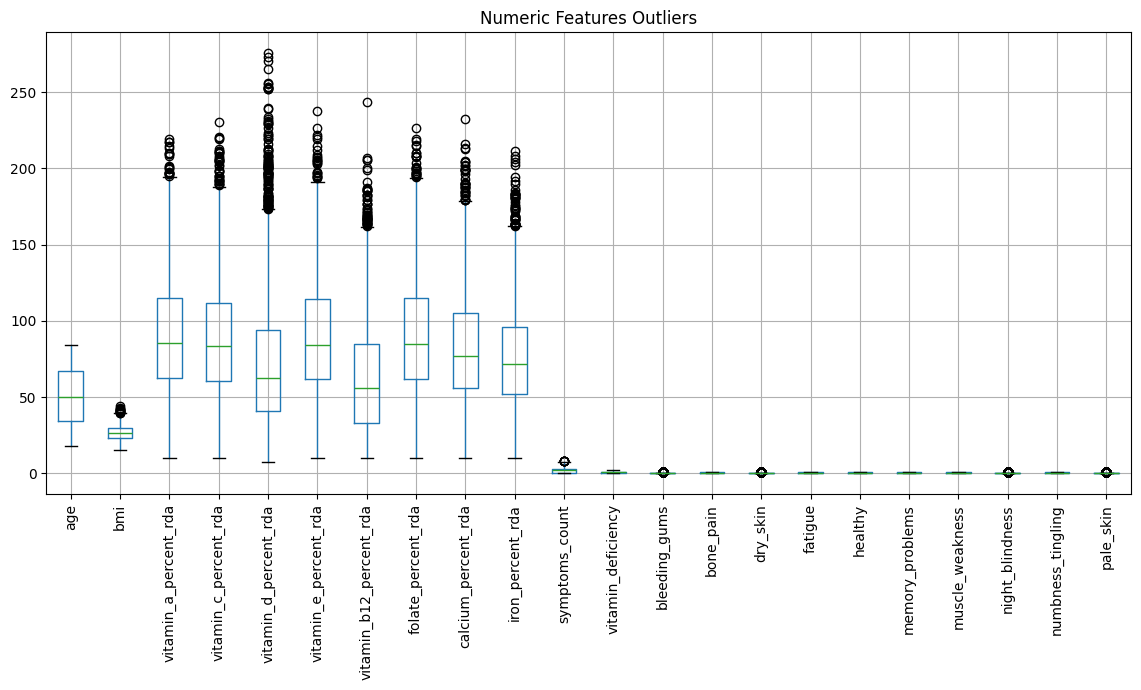

In [187]:
numeric_df = df.select_dtypes(include="number")

numeric_df.boxplot(figsize=(14, 6))
plt.xticks(rotation=90)
plt.title("Numeric Features Outliers")
plt.show()

In [188]:
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

outlier_mask = (numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))
outlier_counts = outlier_mask.sum()

print(outlier_counts.sort_values(ascending=False))

pale_skin                  551
night_blindness            361
dry_skin                   242
bleeding_gums              158
vitamin_d_percent_rda      116
vitamin_b12_percent_rda     54
iron_percent_rda            50
calcium_percent_rda         39
vitamin_c_percent_rda       37
folate_percent_rda          26
vitamin_e_percent_rda       24
vitamin_a_percent_rda       20
bmi                         13
symptoms_count               7
age                          0
vitamin_deficiency           0
bone_pain                    0
fatigue                      0
memory_problems              0
healthy                      0
muscle_weakness              0
numbness_tingling            0
dtype: int64


In [189]:
df.drop(columns=["symptoms_list"], inplace=True)

In [190]:
cat_cols = [col for col in df.columns if df[col].dtype == "object"]
print(cat_cols)

[]


In [191]:
cat_cols = [col for col in df.columns if df[col].nunique() < 20]
print(cat_cols)

['gender', 'smoking_status', 'alcohol_consumption', 'exercise_level', 'diet_type', 'sun_exposure', 'income_level', 'latitude_region', 'symptoms_count', 'bleeding_gums', 'bone_pain', 'dry_skin', 'fatigue', 'healthy', 'memory_problems', 'muscle_weakness', 'night_blindness', 'numbness_tingling', 'pale_skin']


In [192]:
cols = [
    'gender', 'smoking_status', 'alcohol_consumption', 'exercise_level',
    'diet_type', 'sun_exposure', 'income_level', 'latitude_region',
    'symptoms_count', 'bleeding_gums', 'bone_pain', 'dry_skin',
    'fatigue', 'healthy', 'memory_problems', 'muscle_weakness',
    'night_blindness', 'numbness_tingling', 'pale_skin'
]

for col in cols:
    print(f"\n===== {col} =====")
    print(df[col].value_counts(dropna=False))


===== gender =====
gender
Male      1781
Female    1719
Name: count, dtype: int64

===== smoking_status =====
smoking_status
Current    1172
Former     1165
Never      1163
Name: count, dtype: int64

===== alcohol_consumption =====
alcohol_consumption
Moderate    1202
Heavy       1188
sober       1110
Name: count, dtype: int64

===== exercise_level =====
exercise_level
Sedentary    903
Light        884
Active       866
Moderate     847
Name: count, dtype: int64

===== diet_type =====
diet_type
Vegan          887
Pescatarian    876
Omnivore       870
Vegetarian     867
Name: count, dtype: int64

===== sun_exposure =====
sun_exposure
Moderate    1187
High        1170
Low         1143
Name: count, dtype: int64

===== income_level =====
income_level
Low       1187
High      1182
Middle    1131
Name: count, dtype: int64

===== latitude_region =====
latitude_region
High    1187
Low     1175
Mid     1138
Name: count, dtype: int64

===== symptoms_count =====
symptoms_count
0    1152
2     682

In [196]:
#cool so some are ordinal and somee arent those gonna get one hot encoded and the other mapped ok 
df = pd.get_dummies(df, columns=["gender", "diet_type"]),astype(int)




KeyError: "None of [Index(['gender', 'diet_type'], dtype='str')] are in the [columns]"

In [194]:
smoking_map = {
    "Never": 0,
    "Former": 1,
    "Current": 2
}


alcohol_map = {
    "sober": 0,
    "Moderate": 1,
    "Heavy": 2
}


exercise_map = {
    "Sedentary": 0,
    "Light": 1,
    "Moderate": 2,
    "Active": 3
}


sun_map = {
    "Low": 0,
    "Moderate": 1,
    "High": 2
}


income_map = {
    "Low": 0,
    "Middle": 1,
    "High": 2
}


region_map = {
    "Low": 0,
    "Mid": 1,
    "High": 2
}
df["exercise_level"] = df["exercise_level"].map(exercise_map)
df["income_level"] = df["income_level"].map(income_map)
df["sun_exposure"] = df["sun_exposure"].map(sun_map)
df["alcohol_consumption"] = df["alcohol_consumption"].map(alcohol_map)
df["smoking_status"] = df["smoking_status"].map(smoking_map)
df["latitude_region"] = df["latitude_region"].map(region_map)

In [195]:
df.head()

,age,bmi,smoking_status,alcohol_consumption,exercise_level,sun_exposure,income_level,latitude_region,vitamin_a_percent_rda,vitamin_c_percent_rda,...,muscle_weakness,night_blindness,numbness_tingling,pale_skin,gender_Female,gender_Male,diet_type_Omnivore,diet_type_Pescatarian,diet_type_Vegan,diet_type_Vegetarian
0,79,24.8,1,0,3,2,2,1,119.1,147.3,...,0,0,0,0,False,True,False,False,False,True
1,77,39.9,1,1,1,0,0,0,85.7,57.5,...,0,0,0,0,True,False,True,False,False,False
2,24,26.4,1,2,2,0,2,2,48.3,152.1,...,0,1,0,0,False,True,True,False,False,False
3,69,23.1,0,2,2,2,0,0,75.8,51.0,...,0,0,1,0,False,True,False,False,False,True
4,63,29.6,0,0,2,1,2,0,93.3,111.5,...,0,0,0,0,False,True,False,False,False,True


In [197]:
cols = [
    "gender_Female",
    "gender_Male",
    "diet_type_Omnivore",
    "diet_type_Pescatarian",
    "diet_type_Vegan",
    "diet_type_Vegetarian"
]

df[cols] = df[cols].astype(int)

In [198]:
df.head()

,age,bmi,smoking_status,alcohol_consumption,exercise_level,sun_exposure,income_level,latitude_region,vitamin_a_percent_rda,vitamin_c_percent_rda,...,muscle_weakness,night_blindness,numbness_tingling,pale_skin,gender_Female,gender_Male,diet_type_Omnivore,diet_type_Pescatarian,diet_type_Vegan,diet_type_Vegetarian
0,79,24.8,1,0,3,2,2,1,119.1,147.3,...,0,0,0,0,0,1,0,0,0,1
1,77,39.9,1,1,1,0,0,0,85.7,57.5,...,0,0,0,0,1,0,1,0,0,0
2,24,26.4,1,2,2,0,2,2,48.3,152.1,...,0,1,0,0,0,1,1,0,0,0
3,69,23.1,0,2,2,2,0,0,75.8,51.0,...,0,0,1,0,0,1,0,0,0,1
4,63,29.6,0,0,2,1,2,0,93.3,111.5,...,0,0,0,0,0,1,0,0,0,1


In [201]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 34 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      3500 non-null   int64  
 1   bmi                      3500 non-null   float64
 2   smoking_status           3500 non-null   int64  
 3   alcohol_consumption      3500 non-null   int64  
 4   exercise_level           3500 non-null   int64  
 5   sun_exposure             3500 non-null   int64  
 6   income_level             3500 non-null   int64  
 7   latitude_region          3500 non-null   int64  
 8   vitamin_a_percent_rda    3500 non-null   float64
 9   vitamin_c_percent_rda    3500 non-null   float64
 10  vitamin_d_percent_rda    3500 non-null   float64
 11  vitamin_e_percent_rda    3500 non-null   float64
 12  vitamin_b12_percent_rda  3500 non-null   float64
 13  folate_percent_rda       3500 non-null   float64
 14  calcium_percent_rda      3500 non-n

In [200]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["vitamin_deficiency"])
y = df["vitamin_deficiency"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [202]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [205]:
##we gonna use trees as we left the putliers in 
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
#from xgboost import XGBRegressor

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

models = {
    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),
    
      # mafeesh net anazelo bas delwa2t 3shan el xgboost mesh mwgod fel environment beta3y

    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=200,
        random_state=42
    )
}



In [206]:
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)

    results.append([name, r2, rmse, mae])

results_df = pd.DataFrame(results, columns=["Model", "R2", "RMSE", "MAE"])
print(results_df.sort_values(by="R2", ascending=False))

          Model        R2      RMSE       MAE
1    ExtraTrees  0.864027  0.161216  0.123583
0  RandomForest  0.862347  0.162209  0.123005
